# Video + audio human validation — label counts

Reads `human_validation_log.jsonl` under `video_audio_human_validation/` (same default as the app) and plots how many samples were labeled **trash**, **non-cat**, and **cat**.

If the log file is missing, counts `.mp3` files per folder instead.

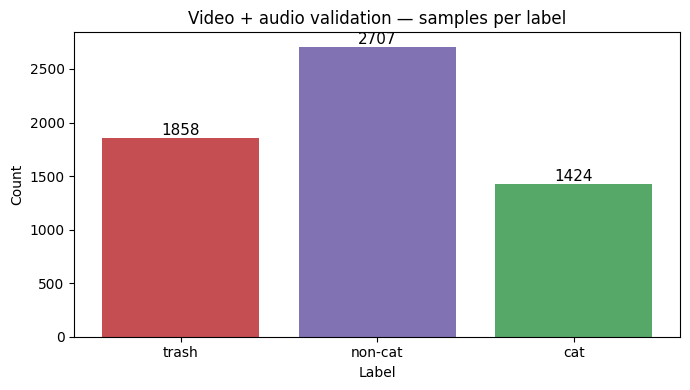

Source: /Users/viktorzozula/Documents/Cats-in-Pain-Bachelors/human_validation_app/video_audio_human_validation/human_validation_log.jsonl
{'trash': 1858, 'non-cat': 2707, 'cat': 1424}


In [3]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

# Same layout as app.py default: repo root contains video_audio_human_validation/
ROOT = Path.cwd()
if (ROOT / "video_audio_human_validation").is_dir():
    VIDEO_AUDIO_ROOT = ROOT / "video_audio_human_validation"
elif (ROOT.parent / "video_audio_human_validation").is_dir():
    VIDEO_AUDIO_ROOT = ROOT.parent / "video_audio_human_validation"
else:
    VIDEO_AUDIO_ROOT = ROOT / "video_audio_human_validation"

LOG = VIDEO_AUDIO_ROOT / "human_validation_log.jsonl"
ORDER = ["trash", "non-cat", "cat"]

labels: list[str] = []
if LOG.is_file():
    with open(LOG, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if rec.get("mode") == "video_audio" and rec.get("label"):
                labels.append(rec["label"])
    counts = Counter(labels)
else:
    counts = Counter()
    if VIDEO_AUDIO_ROOT.is_dir():
        for name in ORDER:
            d = VIDEO_AUDIO_ROOT / name
            if d.is_dir():
                counts[name] = len(list(d.glob("*.mp3")))
    else:
        print(f"Not found: {VIDEO_AUDIO_ROOT}")

# Fixed bar order: trash, non-cat, cat; then any unexpected labels
extras = sorted(k for k in counts if k not in ORDER)
keys = list(ORDER) + extras
values = [counts.get(k, 0) for k in keys]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#c44e52", "#8172b3", "#55a868"]
bar_colors = [colors[ORDER.index(k)] if k in ORDER else "#888888" for k in keys]
ax.bar(keys, values, color=bar_colors)
ax.set_ylabel("Count")
ax.set_xlabel("Label")
ax.set_title("Video + audio validation — samples per label")
for i, v in enumerate(values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Source: {LOG if LOG.is_file() else VIDEO_AUDIO_ROOT}")
print(dict(zip(keys, values)))

# Checking correlation beetwen audio emotion labels and video descriptions

*details are in two seperate subfiles

In [5]:
# Cell 8 — load & join by filename stem (strip extension)
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

PRED_PATH = "video_audio_human_validation/cat_emotion_predictions.jsonl"
DESC_PATH = "video_audio_human_validation/gpt_dataset_descriptions.jsonl"

PROB_COLS = [
    "prob_Angry", "prob_Defence", "prob_Fighting", "prob_Happy",
    "prob_HuntingMind", "prob_Mating", "prob_MotherCall",
    "prob_Paining", "prob_Resting", "prob_Warning",
]
CLASS_LABELS = [c.replace("prob_", "") for c in PROB_COLS]

# --- predictions ---
preds = []
with open(PRED_PATH, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            preds.append(json.loads(line))
df_pred = pd.DataFrame(preds)
df_pred["stem"] = df_pred["filename"].apply(lambda x: Path(x).stem)

# --- descriptions (cat-only, parsed-ok) ---
descs = []
with open(DESC_PATH, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        if rec["folder_label"] != "cat" or not rec["parse_ok"]:
            continue
        flat = {"stem": Path(rec["video_path"]).stem}
        flat.update(rec["gpt_response"])
        descs.append(flat)
df_desc = pd.DataFrame(descs)

# --- join ---
df = df_pred.merge(df_desc, on="stem", how="inner")
print(f"Predictions : {len(df_pred)}")
print(f"Descriptions: {len(df_desc)}")
print(f"Joined      : {len(df)}  ({len(df_pred)-len(df)} predictions unmatched)")
df.head(2)

Predictions : 1424
Descriptions: 1424
Joined      : 1424  (0 predictions unmatched)


,filepath,filename,predicted_class_idx,predicted_class,confidence,prob_Angry,prob_Defence,prob_Fighting,prob_Happy,prob_HuntingMind,...,environment,scene_type,lighting,occlusion,visual_clarity,human_presence,other_animals_present,other_animals,cat_visual_type,overall_confidence
0,/Users/viktorzozula/Documents/Cats-in-Pain-Bac...,Кот ненавидит ватные палочки_snip_4.mp3,9,Warning,0.603604,0.000172,0.013952,0.001900,0.001232,0.106271,...,indoor,home,low_light,partial,slightly_blurry,no,no,[],tabby,high
1,/Users/viktorzozula/Documents/Cats-in-Pain-Bac...,TPtYACCKEto_snip_0_1.mp3,3,Happy,0.746027,0.000952,0.001411,0.001501,0.746027,0.191057,...,indoor,home,normal_indoor,partial,clear,yes,no,[],siamese_like,high


/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_24056/1778605981.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="predicted_class", order=order, palette="muted", ax=axes[0])
/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_24056/1778605981.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=norm.index, y=norm.values, palette="muted", ax=axes[1])


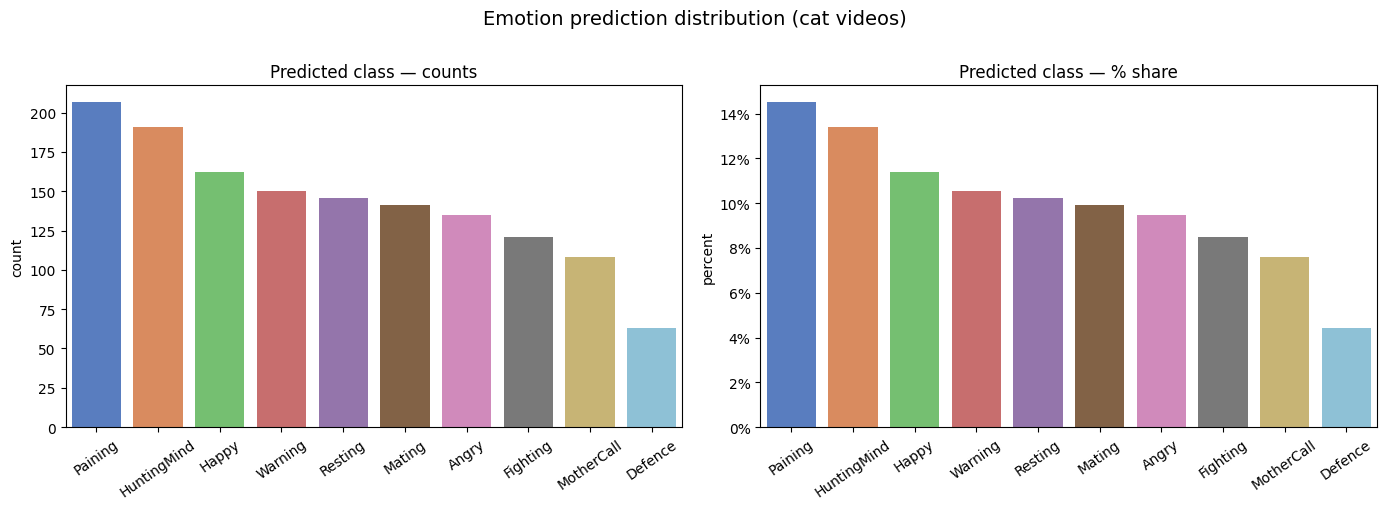

In [6]:
# Cell 9 — predicted class distribution (counts + share)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df["predicted_class"].value_counts().index.tolist()

sns.countplot(data=df, x="predicted_class", order=order, palette="muted", ax=axes[0])
axes[0].set_title("Predicted class — counts")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

norm = df["predicted_class"].value_counts(normalize=True).mul(100).reindex(order)
sns.barplot(x=norm.index, y=norm.values, palette="muted", ax=axes[1])
axes[1].set_title("Predicted class — % share")
axes[1].set_ylabel("percent")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
axes[1].tick_params(axis="x", rotation=35)

plt.suptitle("Emotion prediction distribution (cat videos)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

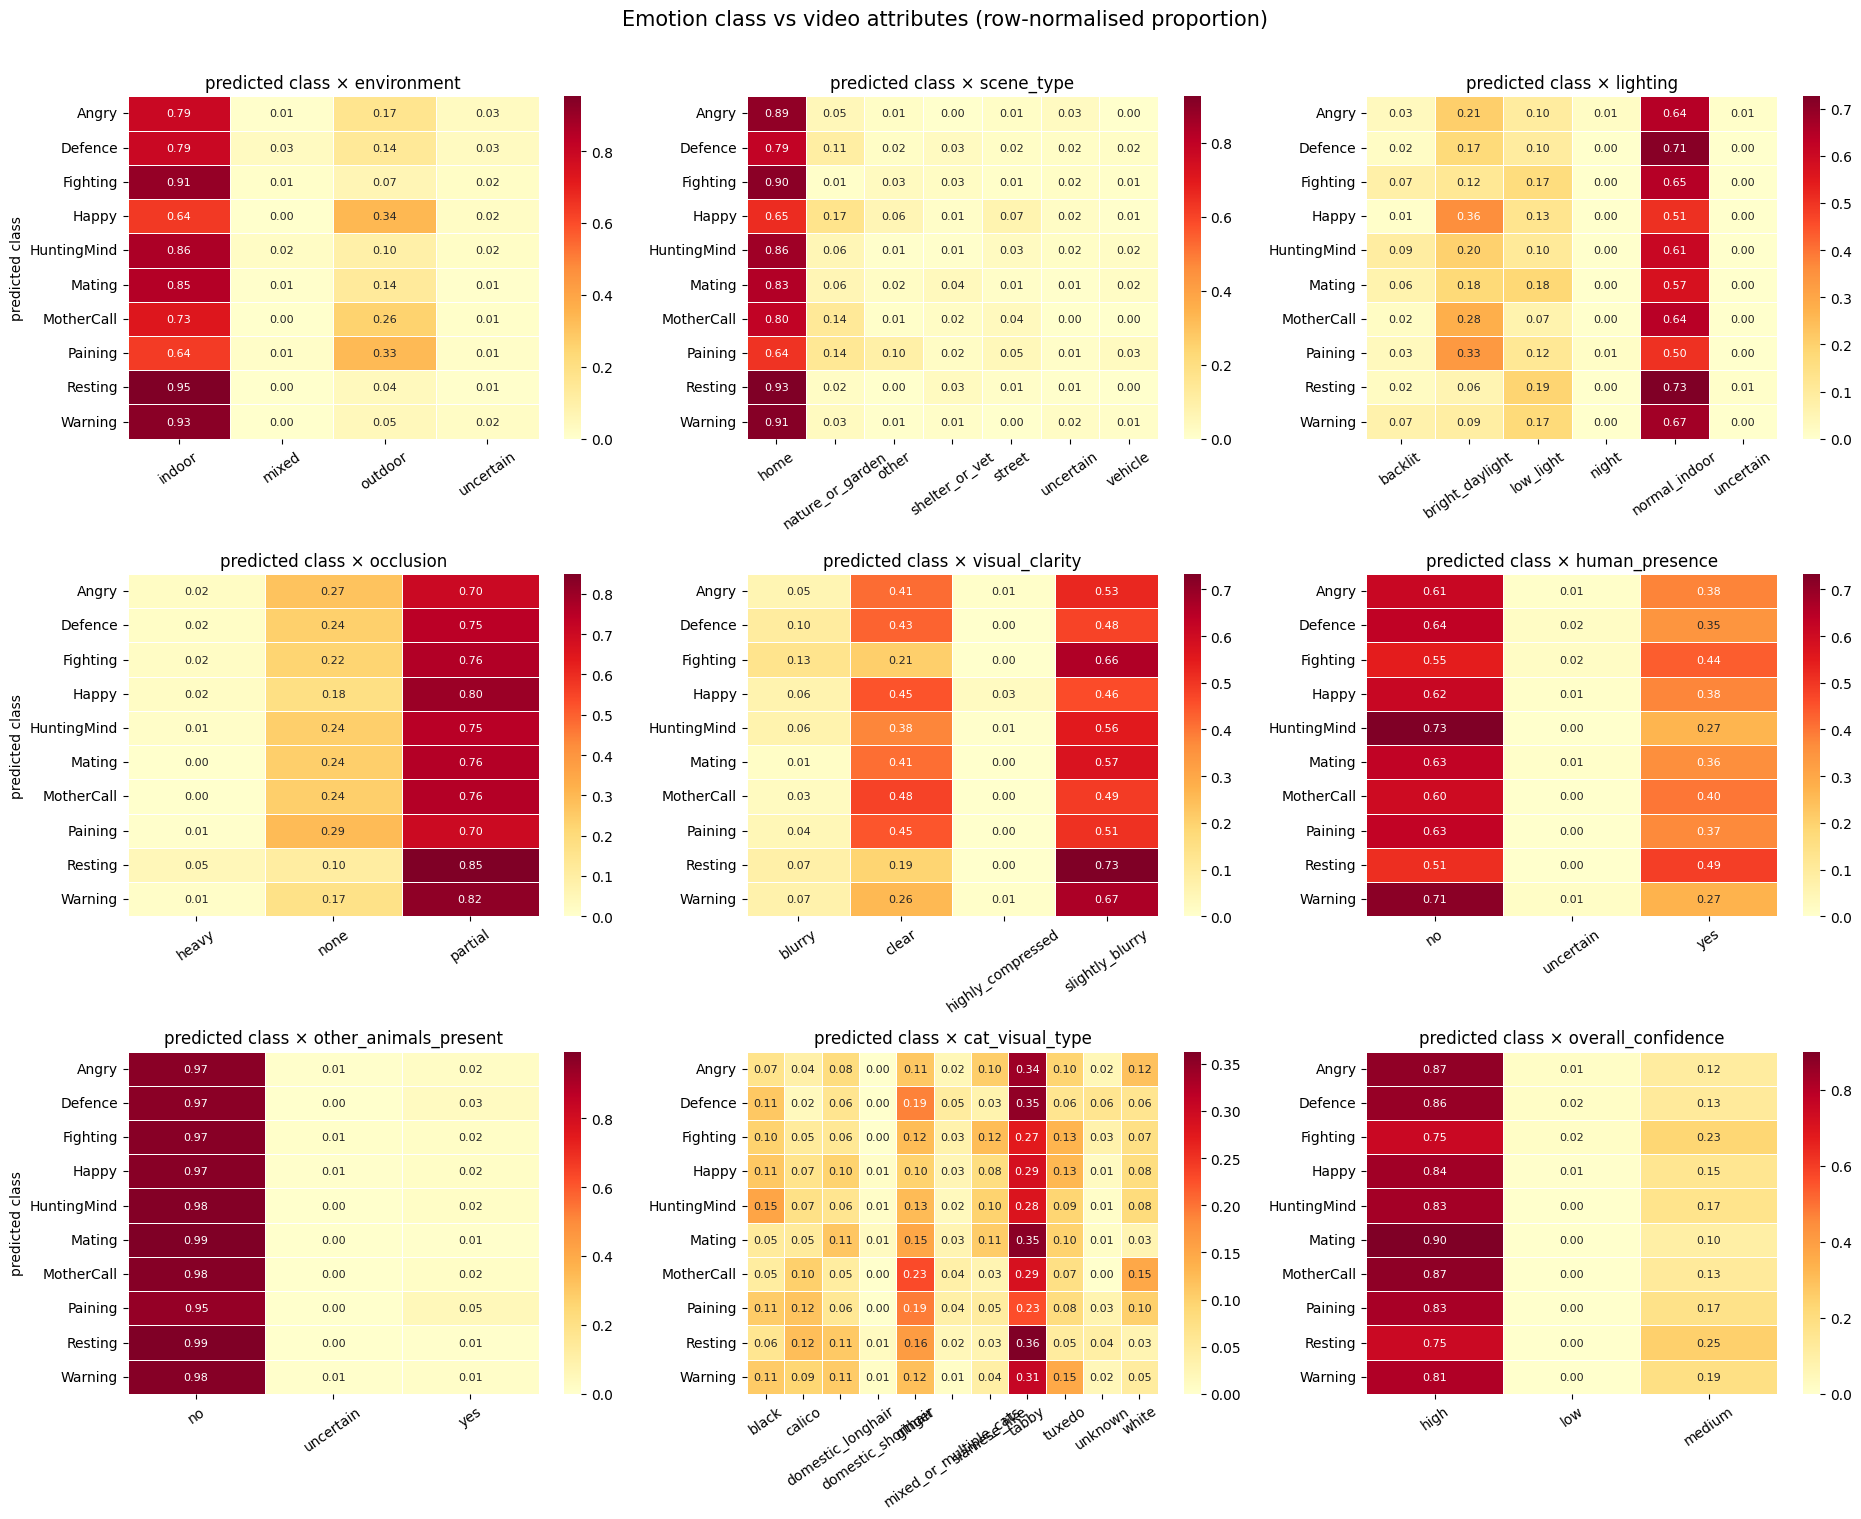

In [7]:
# Cell 10 — heatmap: predicted_class × each visual attribute (row-normalised)
VISUAL_COLS = [
    "environment", "scene_type", "lighting",
    "occlusion", "visual_clarity", "human_presence",
    "other_animals_present", "cat_visual_type", "overall_confidence",
]

n_cols = 3
n_rows = -(-len(VISUAL_COLS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(19, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(VISUAL_COLS):
    ct = pd.crosstab(df["predicted_class"], df[col], normalize="index").round(3)
    sns.heatmap(
        ct, annot=True, fmt=".2f", cmap="YlOrRd",
        linewidths=0.4, ax=axes[i], cbar=True,
        annot_kws={"size": 8}
    )
    axes[i].set_title(f"predicted class × {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("predicted class" if i % n_cols == 0 else "")
    axes[i].tick_params(axis="x", rotation=35)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Emotion class vs video attributes (row-normalised proportion)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_24056/1310436532.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_cat, labels=cats, patch_artist=True,
/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_24056/1310436532.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_cat, labels=cats, patch_artist=True,
/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_24056/1310436532.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_cat, labels=cats, patch_artist=True,
/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_24056/13104

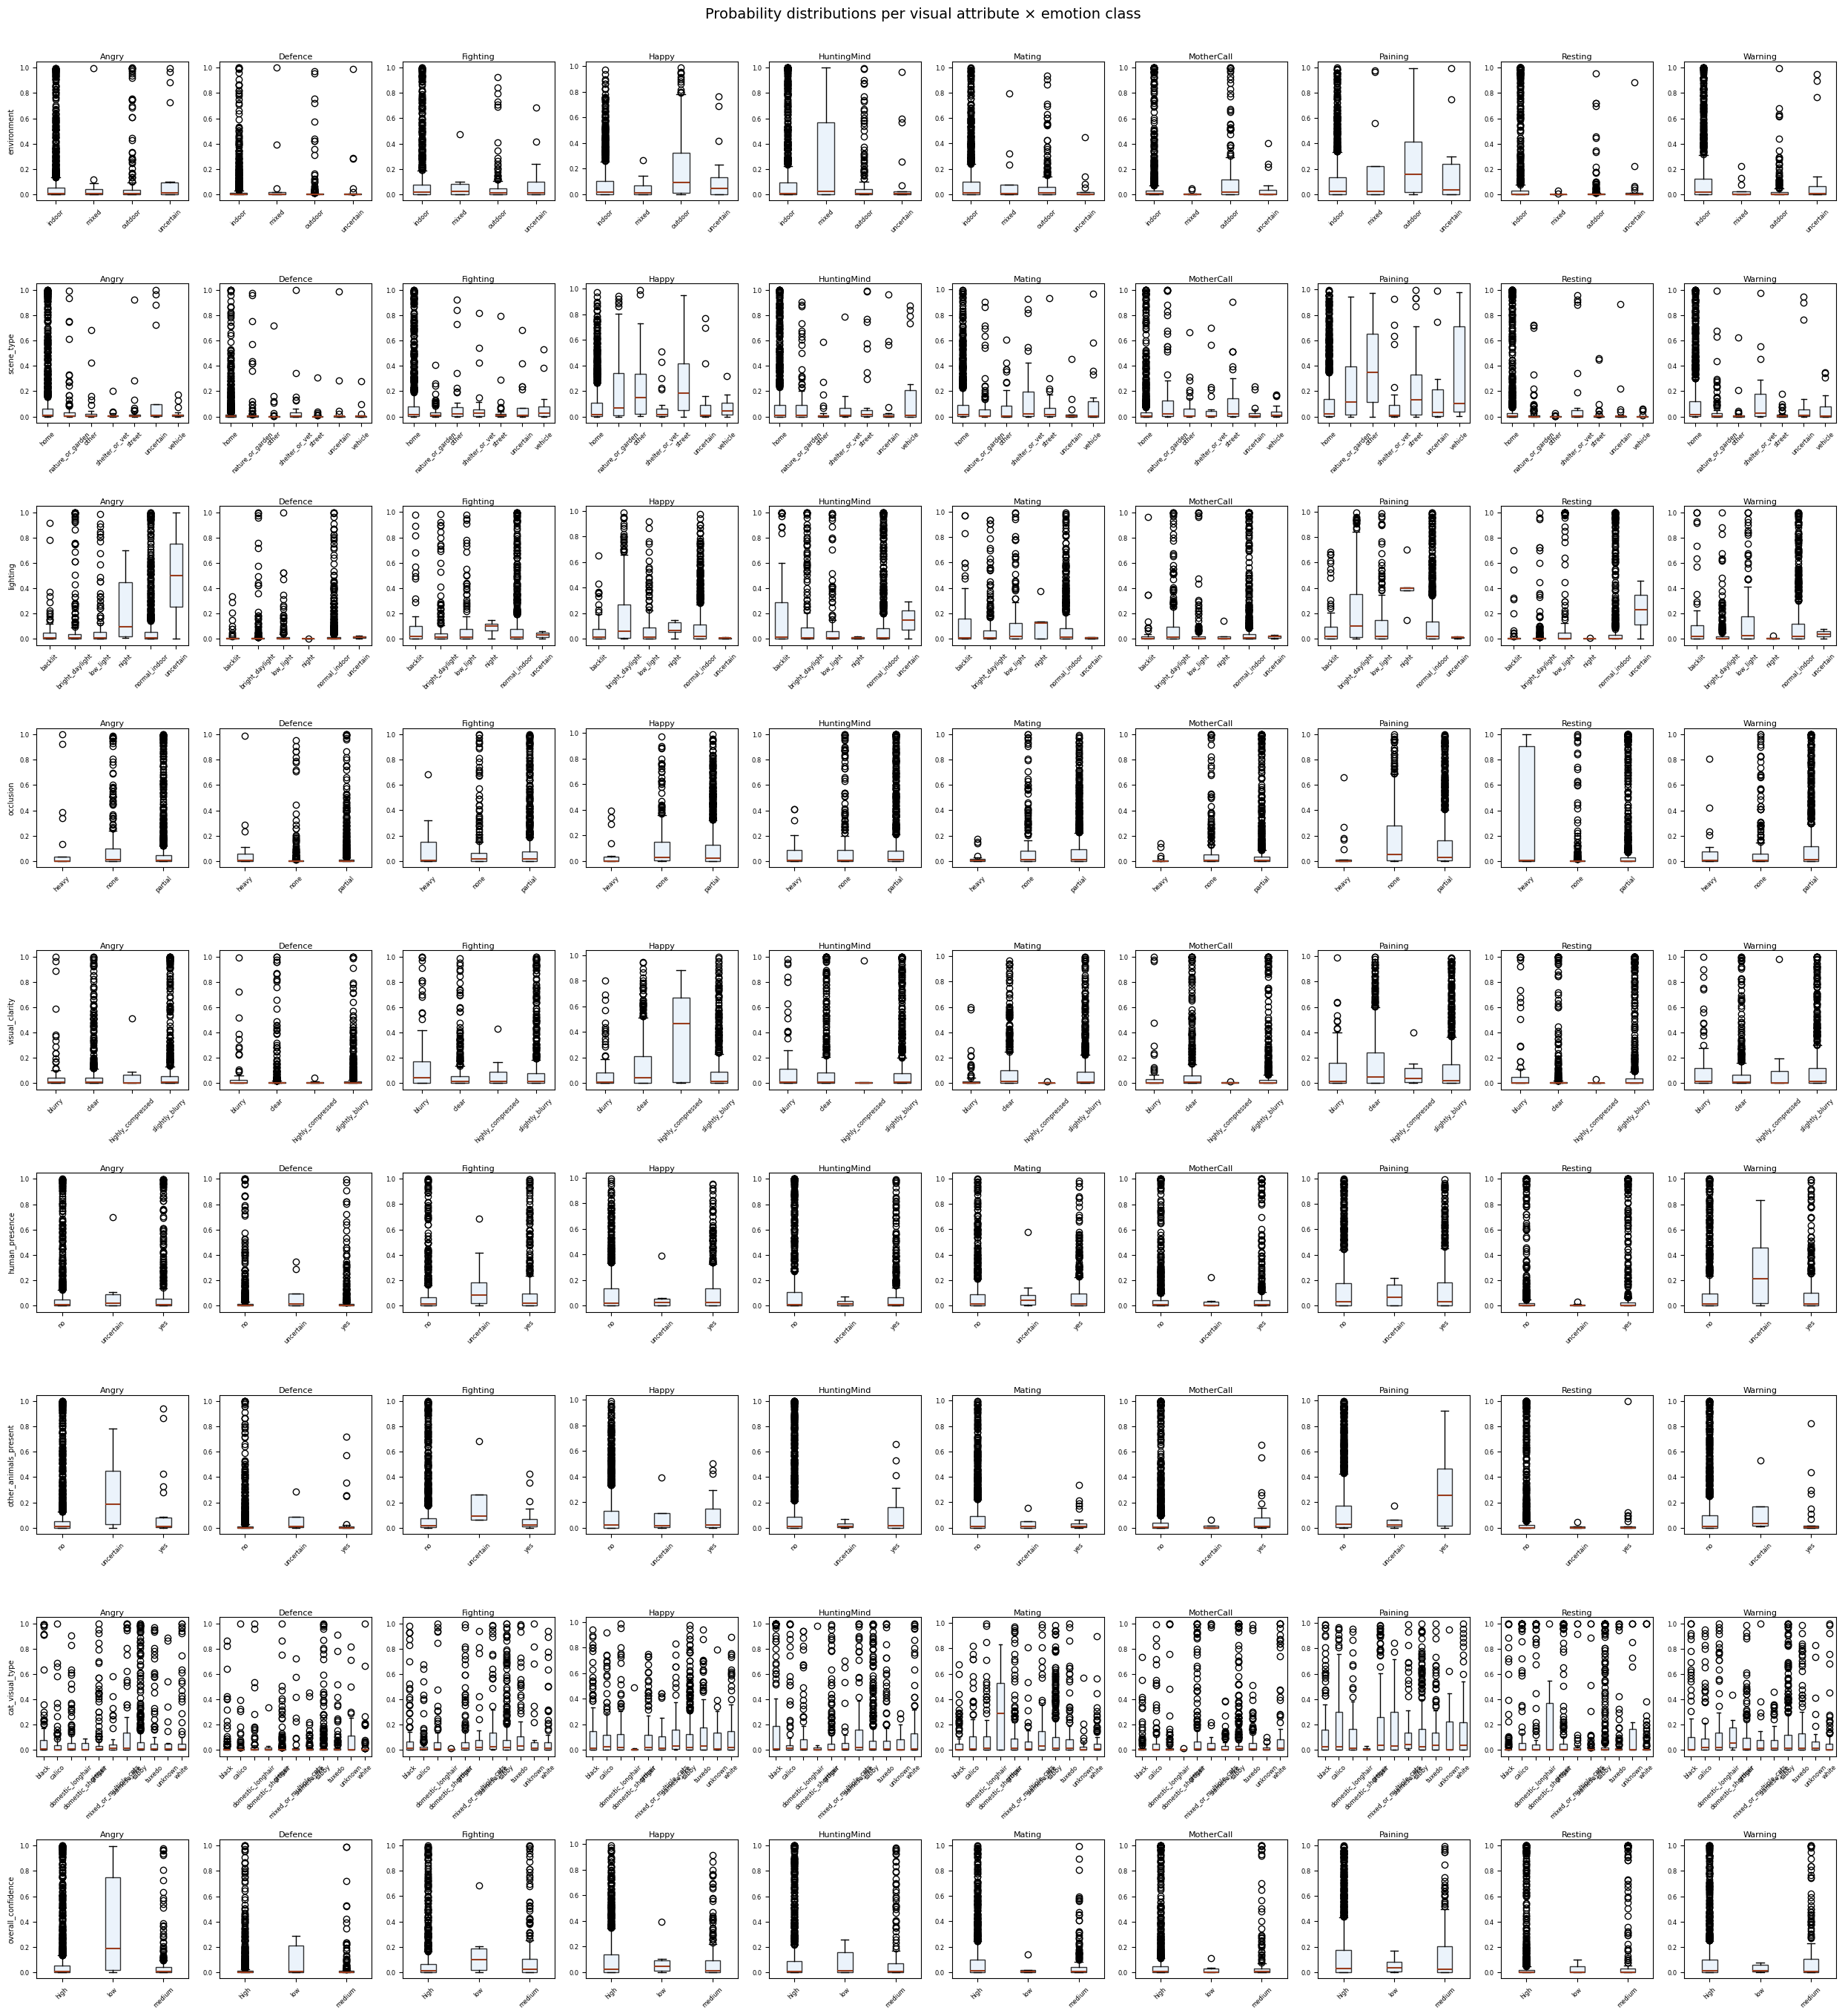

In [8]:
# Cell 11 — mean class probabilities per visual category (violin per attribute)
# Shows whether a category shifts the full probability distribution, not just the argmax

fig, axes = plt.subplots(len(VISUAL_COLS), len(PROB_COLS),
                          figsize=(len(PROB_COLS) * 2.5, len(VISUAL_COLS) * 3))

for row, vcol in enumerate(VISUAL_COLS):
    for col, pcol in enumerate(PROB_COLS):
        ax = axes[row][col]
        cats = sorted(df[vcol].unique())
        data_by_cat = [df.loc[df[vcol] == c, pcol].values for c in cats]
        ax.boxplot(data_by_cat, labels=cats, patch_artist=True,
                   medianprops=dict(color="#993C1D", linewidth=1.5),
                   boxprops=dict(facecolor="#E6F1FB", alpha=0.8))
        ax.set_title(pcol.replace("prob_", ""), fontsize=8, pad=2)
        ax.tick_params(axis="x", rotation=45, labelsize=6)
        ax.tick_params(axis="y", labelsize=6)
        if col == 0:
            ax.set_ylabel(vcol, fontsize=7)

plt.suptitle("Probability distributions per visual attribute × emotion class", fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_24056/3899153618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="predicted_class", y="confidence",
/var/folders/vb/9lm3mj5n1_573j4kn1bw4fnc0000gn/T/ipykernel_24056/3899153618.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="environment", y="confidence",


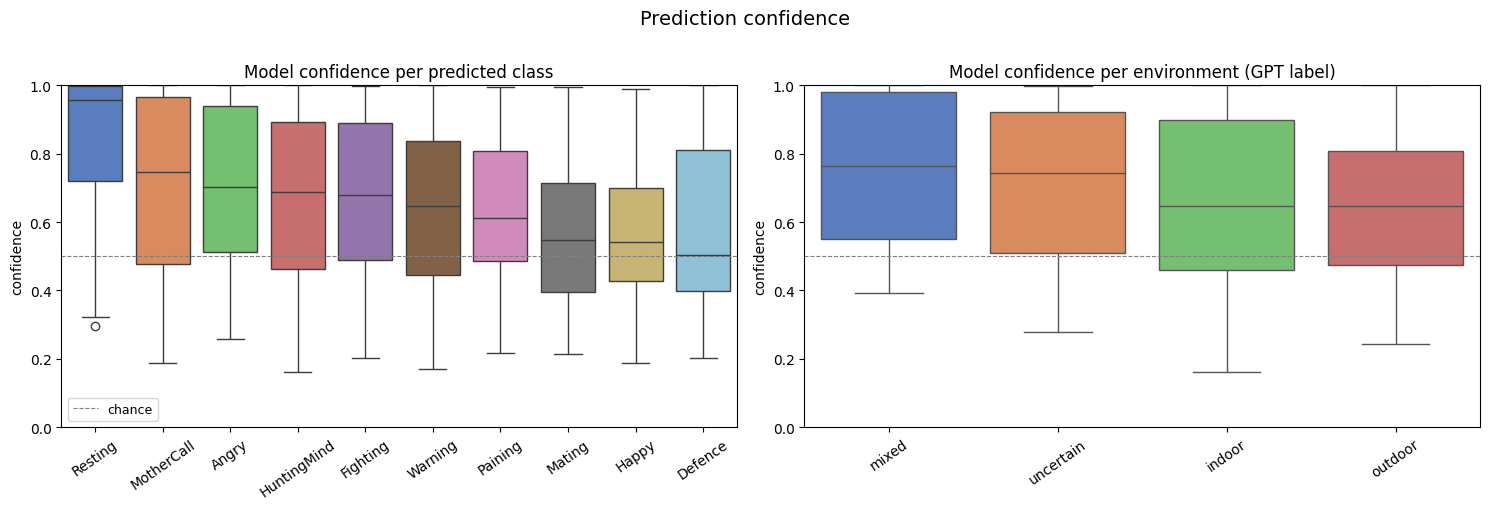

In [9]:
# Cell 13 — confidence distribution per class + per environment
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = df.groupby("predicted_class")["confidence"].median().sort_values(ascending=False).index

sns.boxplot(data=df, x="predicted_class", y="confidence",
            order=order, palette="muted", ax=axes[0])
axes[0].set_title("Model confidence per predicted class")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance")
axes[0].legend(fontsize=9)

env_order = df.groupby("environment")["confidence"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="environment", y="confidence",
            order=env_order, palette="muted", ax=axes[1])
axes[1].set_title("Model confidence per environment (GPT label)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("Prediction confidence", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Cell 14 — text summary report for LLM analysis
from io import StringIO

lines = []

def h(title):
    lines.append(f"\n{'='*60}")
    lines.append(title.upper())
    lines.append('='*60)

def section(title):
    lines.append(f"\n--- {title} ---")

# ── header ────────────────────────────────────────────────────
h("Cat emotion prediction dataset — summary report")
lines.append(f"Total matched records : {len(df)}")
lines.append(f"Unmatched predictions : {len(df_pred) - len(df)}")
lines.append(f"Unmatched descriptions: {len(df_desc) - len(df)}")

# ── class distribution ────────────────────────────────────────
h("1. predicted class distribution")
vc = df["predicted_class"].value_counts()
for cls, cnt in vc.items():
    pct = cnt / len(df) * 100
    lines.append(f"  {cls:<15} {cnt:>4}  ({pct:.1f}%)")

# ── confidence per class ──────────────────────────────────────
h("2. model confidence per predicted class")
conf = df.groupby("predicted_class")["confidence"].agg(["mean", "median", "std", "min", "max"])
for cls, row in conf.sort_values("median", ascending=False).iterrows():
    lines.append(
        f"  {cls:<15}  mean={row['mean']:.3f}  median={row['median']:.3f}"
        f"  std={row['std']:.3f}  range=[{row['min']:.3f}, {row['max']:.3f}]"
    )

# ── mean probabilities per class ─────────────────────────────
h("3. mean softmax probabilities per predicted class")
prob_means = df.groupby("predicted_class")[PROB_COLS].mean()
prob_means.columns = CLASS_LABELS
for cls, row in prob_means.iterrows():
    top3 = row.sort_values(ascending=False).head(3)
    top3_str = "  |  ".join([f"{k}={v:.3f}" for k, v in top3.items()])
    lines.append(f"  {cls:<15}  top-3 probs: {top3_str}")

# ── visual attributes × predicted class ──────────────────────
h("4. visual attribute distributions per predicted class")
for vcol in VISUAL_COLS:
    section(vcol)
    ct = pd.crosstab(df["predicted_class"], df[vcol], normalize="index").round(3)
    for cls, row in ct.iterrows():
        dominant = row.sort_values(ascending=False).head(2)
        dom_str = "  |  ".join([f"{k}={v:.2f}" for k, v in dominant.items()])
        lines.append(f"  {cls:<15}  dominant: {dom_str}")

# ── notable correlations (simple flag) ───────────────────────
h("5. potentially notable correlations (proportion >= 0.60)")
lines.append("Classes where a single attribute value accounts for >= 60% of that class:")
for vcol in VISUAL_COLS:
    ct = pd.crosstab(df["predicted_class"], df[vcol], normalize="index")
    for cls in ct.index:
        for attr_val in ct.columns:
            val = ct.loc[cls, attr_val]
            if val >= 0.60:
                n = df[(df["predicted_class"] == cls) & (df[vcol] == attr_val)].shape[0]
                lines.append(f"  [{vcol}]  {cls:<15} -> {attr_val:<20}  {val:.2f}  (n={n})")

# ── confidence vs visual clarity ─────────────────────────────
h("6. mean confidence per visual clarity level")
vc_conf = df.groupby("visual_clarity")["confidence"].agg(["mean", "median", "count"])
for vc_val, row in vc_conf.sort_values("mean", ascending=False).iterrows():
    lines.append(
        f"  {vc_val:<20}  mean={row['mean']:.3f}  median={row['median']:.3f}  n={int(row['count'])}"
    )

# ── environment breakdown ─────────────────────────────────────
h("7. class distribution per environment")
for env, grp in df.groupby("environment"):
    dist = grp["predicted_class"].value_counts()
    dist_str = "  |  ".join([f"{k}={v}" for k, v in dist.items()])
    lines.append(f"  {env:<12}  (n={len(grp)})  {dist_str}")

# ── raw probability summary ───────────────────────────────────
h("8. global mean softmax probabilities (all records)")
global_means = df[PROB_COLS].mean().sort_values(ascending=False)
for col, val in global_means.items():
    lines.append(f"  {col.replace('prob_', ''):<15}  {val:.4f}")

# ── assemble & print ──────────────────────────────────────────
report = "\n".join(lines)
print(report)

# optionally save to file
report_path = Path("llm_summary_report.txt")
report_path.write_text(report, encoding="utf-8")
print(f"\n\nReport saved to: {report_path.resolve()}")


CAT EMOTION PREDICTION DATASET — SUMMARY REPORT
Total matched records : 1424
Unmatched predictions : 0
Unmatched descriptions: 0

1. PREDICTED CLASS DISTRIBUTION
  Paining          207  (14.5%)
  HuntingMind      191  (13.4%)
  Happy            162  (11.4%)
  Warning          150  (10.5%)
  Resting          146  (10.3%)
  Mating           141  (9.9%)
  Angry            135  (9.5%)
  Fighting         121  (8.5%)
  MotherCall       108  (7.6%)
  Defence           63  (4.4%)

2. MODEL CONFIDENCE PER PREDICTED CLASS
  Resting          mean=0.850  median=0.956  std=0.192  range=[0.297, 1.000]
  MotherCall       mean=0.707  median=0.747  std=0.257  range=[0.186, 1.000]
  Angry            mean=0.702  median=0.703  std=0.232  range=[0.259, 1.000]
  HuntingMind      mean=0.671  median=0.688  std=0.249  range=[0.161, 1.000]
  Fighting         mean=0.665  median=0.680  std=0.223  range=[0.204, 0.999]
  Warning          mean=0.643  median=0.648  std=0.231  range=[0.170, 1.000]
  Paining          